In [ ]:
!pip install deap

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/perovskite/raw_data_b2.csv')
df2 = pd.read_csv('/content/drive/MyDrive/perovskite/raw_data_b3.csv')
df = pd.concat([df1,df2],ignore_index=True)

In [ ]:
df.drop(['Unnamed: 0','material_id','formula','A','B1','B3','X',"formation_energy_per_atom"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219 entries, 0 to 1218
Data columns (total 30 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   band_gap      1219 non-null   float64
 1   e_above_hull  1219 non-null   float64
 2   R-A(pm)       1219 non-null   float64
 3   I-A(kJ/mol)   1219 non-null   float64
 4   V-A           1219 non-null   float64
 5   P-A           1219 non-null   float64
 6   E-A(kJ/mol)   1219 non-null   float64
 7   N-A           1219 non-null   float64
 8   R-B1(pm)      1219 non-null   float64
 9   X-B1(kJ/mol)  1219 non-null   float64
 10  V-B1          1219 non-null   float64
 11  P-B1          1219 non-null   float64
 12  E-B1(kJ/mol)  1219 non-null   float64
 13  N-B1          1219 non-null   float64
 14  R-B3(pm)      1219 non-null   float64
 15  X-B3(kJ/mol)  1219 non-null   float64
 16  V-B3          1219 non-null   float64
 17  P-B3          1219 non-null   float64
 18  E-B3(kJ/mol)  1219 non-null 

In [ ]:
correlation_with_band_gap = df.corr()['e_above_hull']
correlation_with_band_gap

,e_above_hull
band_gap,-0.246138
e_above_hull,1.000000
R-A(pm),-0.240975
I-A(kJ/mol),0.297608
V-A,NaN
P-A,-0.285036
E-A(kJ/mol),0.270815
N-A,-0.191546
R-B1(pm),-0.045973
X-B1(kJ/mol),0.122531


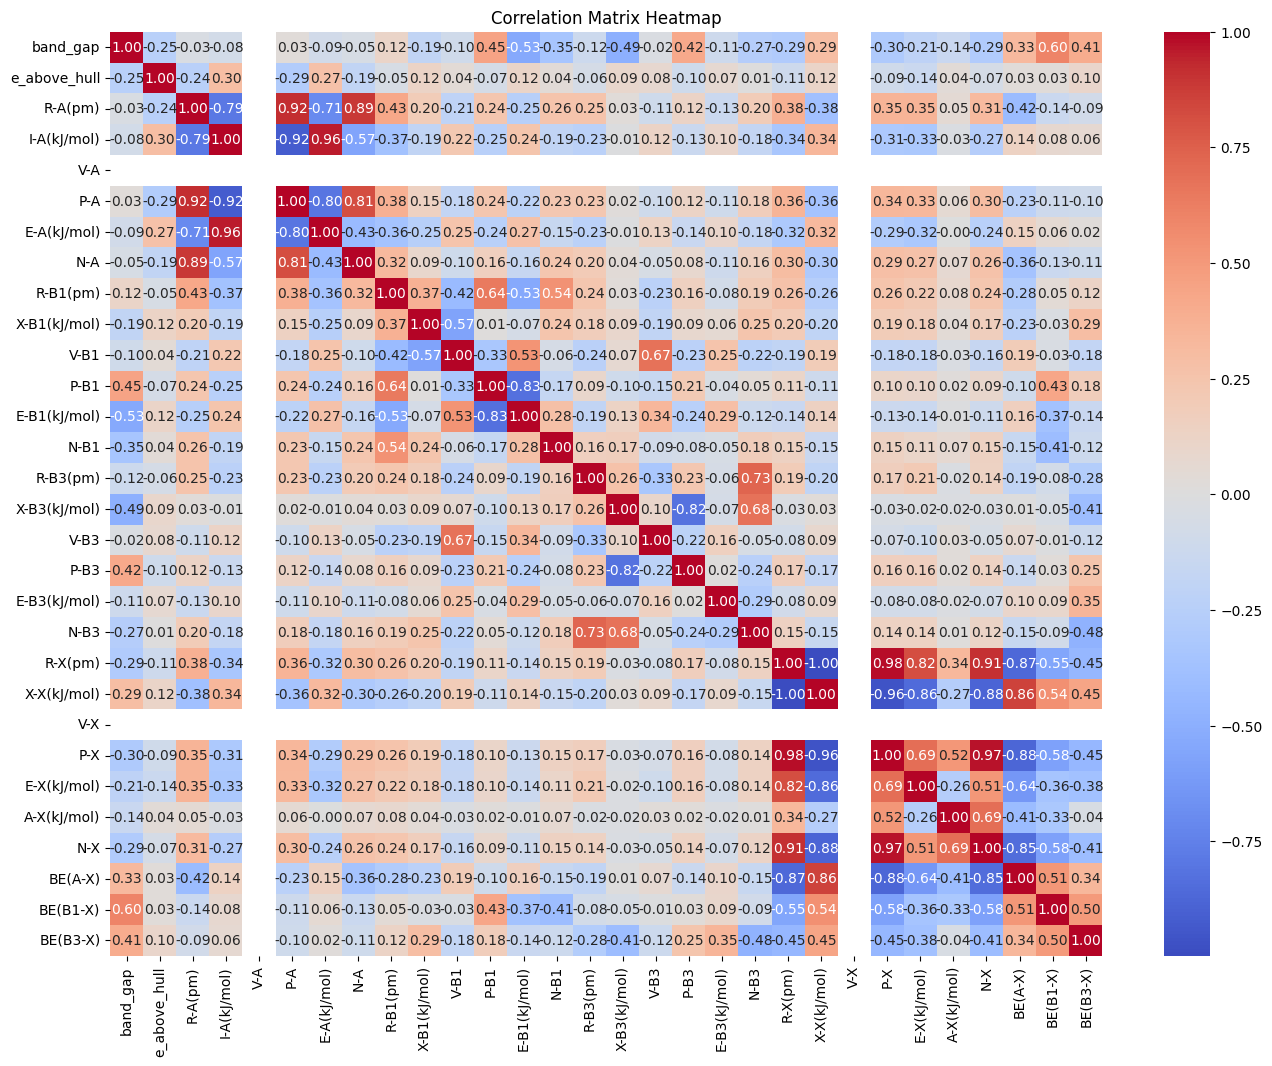

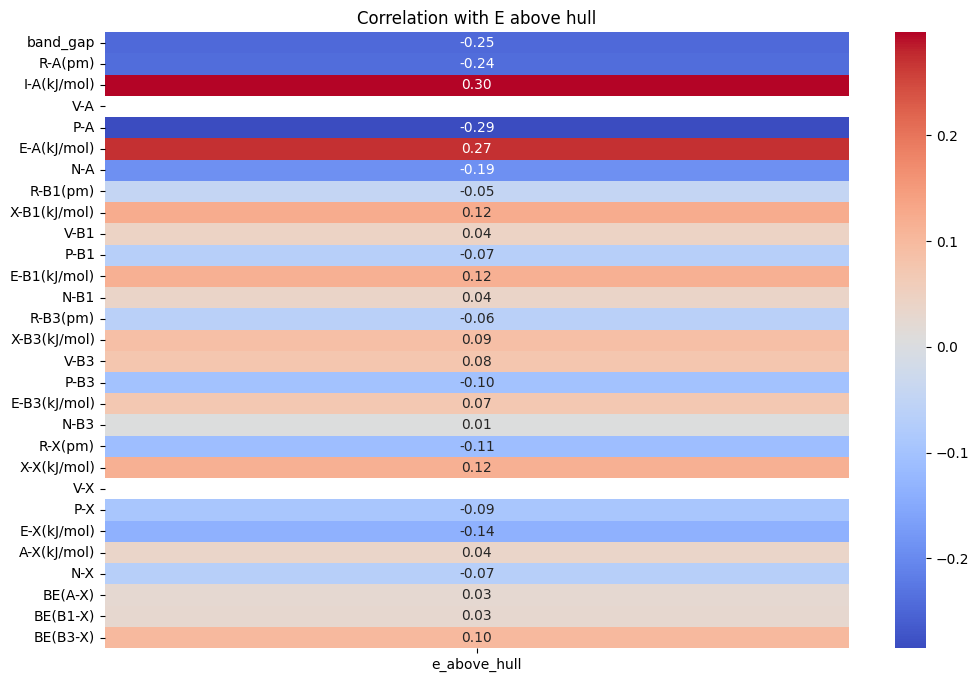

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

plt.figure(figsize=(12, 8))
correlation_with_band_gap = df.corr()['e_above_hull']
correlation_with_band_gap = correlation_with_band_gap.drop('e_above_hull')
sns.heatmap(correlation_with_band_gap.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with E above hull')
plt.show()


In [ ]:
# columns_to_drop = correlation_with_band_gap[abs(correlation_with_band_gap) < 0.10].index
columns_to_drop = ['R-B1(pm)', 'V-B1', 'P-B1', 'N-B1', 'R-B3(pm)', 'X-B3(kJ/mol)', 'V-B3',
       'E-B3(kJ/mol)', 'N-B3', 'P-X', 'A-X(kJ/mol)', 'N-X', 'BE(A-X)',
       'BE(B1-X)']

In [ ]:
df.drop(columns_to_drop,axis=1,inplace=True)

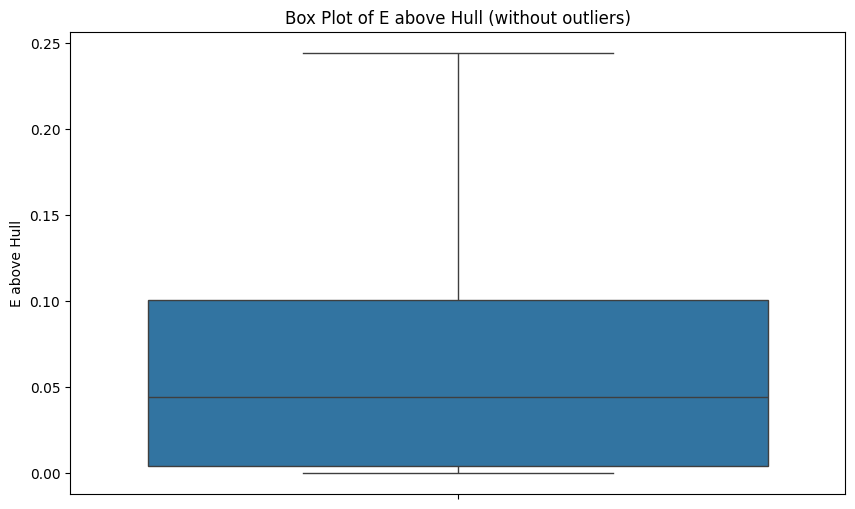

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['e_above_hull'], showfliers=False) # showfliers=False removes outliers
plt.title('Box Plot of E above Hull (without outliers)')
plt.ylabel('E above Hull')
plt.show()

In [ ]:
df[df["e_above_hull"]<=.025].info()

<class 'pandas.core.frame.DataFrame'>
Index: 468 entries, 0 to 1218
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   band_gap      468 non-null    float64
 1   e_above_hull  468 non-null    float64
 2   R-A(pm)       468 non-null    float64
 3   I-A(kJ/mol)   468 non-null    float64
 4   V-A           468 non-null    float64
 5   P-A           468 non-null    float64
 6   E-A(kJ/mol)   468 non-null    float64
 7   N-A           468 non-null    float64
 8   X-B1(kJ/mol)  468 non-null    float64
 9   E-B1(kJ/mol)  468 non-null    float64
 10  P-B3          468 non-null    float64
 11  R-X(pm)       468 non-null    float64
 12  X-X(kJ/mol)   468 non-null    float64
 13  V-X           468 non-null    float64
 14  E-X(kJ/mol)   468 non-null    float64
 15  BE(B3-X)      437 non-null    float64
dtypes: float64(16)
memory usage: 62.2 KB


In [ ]:
df['stable'] = df['e_above_hull'].apply(lambda x: 1 if x < 0.025 else 0)

In [ ]:
df['stable'].value_counts()

,count
stable,
0,751
1,468


In [ ]:
df.drop('e_above_hull',axis=1,inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score,precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
import warnings

In [ ]:
df.columns

Index(['band_gap', 'R-A(pm)', 'I-A(kJ/mol)', 'V-A', 'P-A', 'E-A(kJ/mol)',
       'N-A', 'X-B1(kJ/mol)', 'E-B1(kJ/mol)', 'P-B3', 'R-X(pm)', 'X-X(kJ/mol)',
       'V-X', 'E-X(kJ/mol)', 'BE(B3-X)', 'stable'],
      dtype='object')

In [ ]:
# train test spilt

y_total = df["stable"]
X_total = df.drop(["stable"],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_total,y_total,test_size=0.3,random_state=101)


In [ ]:
import random
from deap import base, creator, tools, algorithms


warnings.filterwarnings('ignore')

# --- Configuration ---
# Define the bounds and types for each hyperparameter
# Order: learning_rate, max_depth, n_estimators, subsample, reg_lambda, reg_alpha, gamma, colsample_bylevel, colsample_bytree
HP_BOUNDS_LOW = [0.01, 3, 50, 0.5, 0, 0, 0, 0.5, 0.5]
HP_BOUNDS_HIGH = [0.3, 15, 500, 1.0, 10, 10, 5, 1.0, 1.0]
# 0: continuous, 1: discrete
HP_TYPES = [0, 1, 1, 0, 0, 0, 0, 0, 0]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters
POPULATION_SIZE = 50
NUM_GENERATIONS = 50
CXPB = 0.7 # Crossover probability
MUTPB = 0.3 # Mutation probability

# --- DEAP Setup ---
# Define the fitness function (minimize MSE)
# We use 'weights=(-1.0,)' because DEAP minimizes by default, and we want to minimize MSE
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# Define the individual (a list of hyperparameters)
# The individual will have the defined fitness attribute
creator.create("Individual", list, fitness=creator.FitnessMin)

# Create a toolbox to hold the evolutionary operators
toolbox = base.Toolbox()

# Attribute generator: Generate a random value within the bounds for each hyperparameter
# This function will be used to create the initial population
def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    if HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

# Register the attribute generator for each hyperparameter
for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

# Structure initializer: Create an individual by combining the attributes
# The individual will be a list of hyperparameters generated by the attribute generators
toolbox.register("individual", tools.initCycle, creator.Individual,
                 tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]), n=1)

# Population initializer: Create a list of individuals
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function ---
def evalXGB(individual, X_train, y_train, X_val, y_val):
    """
    Evaluates the fitness of an individual (set of hyperparameters)
    by training an XGBoost Regressor and calculating the Mean Squared Error
    on the validation set.
    """
    # Decode the hyperparameters from the individual
    hyperparameters = {
        'learning_rate': individual[0],
        'max_depth': int(individual[1]), # Cast discrete to int
        'n_estimators': int(individual[2]), # Cast discrete to int
        'subsample': individual[3],
        'reg_lambda': individual[4],
        'reg_alpha': individual[5],
        'gamma': individual[6],
        'colsample_bylevel': individual[7],
        'colsample_bytree': individual[8]
    }

    # Ensure max_depth and n_estimators are at least 1
    hyperparameters['max_depth'] = max(1, hyperparameters['max_depth'])
    hyperparameters['n_estimators'] = max(1, hyperparameters['n_estimators'])


    try:
        # Instantiate the XGBoost Regressor model with the current hyperparameters
        model = XGBClassifier(objective='binary:logistic',
                                 eval_metric='logloss',
                                 use_label_encoder=False,
                                 random_state=42,
                                 n_jobs=-1,
                                 **hyperparameters)

        model.fit(X_train, y_train)

        predictions = model.predict(X_val)

        recall = recall_score(y_val, predictions)

        return (-recall,)

    except Exception as e:
        # Handle potential errors during training (e.g., invalid hyperparameters)
        return (float('inf'),) # Assign infinity as fitness

# Register the evaluation function with the toolbox
toolbox.register("evaluate", evalXGB, X_train=None, y_train=None, X_val=None, y_val=None) # Will set data later

# --- Genetic Operators ---
# Register the crossover operator
toolbox.register("mate", tools.cxTwoPoint)

# Register the mutation operator (e.g., Gaussian mutation)
# We use a custom mutation to respect the bounds and types of hyperparameters
def mutate_hyperparameters(individual, mu, sigma, indpb):
    """Mutate an individual's hyperparameters while respecting bounds and types."""
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb: # Mutate with probability indpb
            if hp_type == 0:
                # Apply Gaussian mutation
                individual[i] += random.gauss(mu, sigma[i])
                # Ensure bounds are respected
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            else:
                # Apply integer mutation (add random integer within a range)
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

# Register the custom mutation operator
# Adjust sigma based on the range of each hyperparameter
hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [r * 0.1 for r in hp_ranges] # mutation strength is 10% of the range
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.1) # indpb is the probability of mutating each attribute

# Register the selection operator (e.g., tournament selection)
toolbox.register("select", tools.selTournament, tournsize=3)

# --- Main Evolutionary Loop ---
if __name__ == '__main__':



    toolbox.unregister("evaluate") # Unregister the placeholder
    toolbox.register("evaluate", evalXGB, X_train=X_train, y_train=y_train, X_val=X_test, y_val=y_test)

    # Create the initial population
    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    #  Evaluate the fitness of the initial population
    print("Evaluating initial population...")
    # Map the evaluation function to the individuals
    fitnesses = list(map(toolbox.evaluate, population))
    # Assign the calculated fitness values to the individuals
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    # Keep track of the best individual found so far
    hof = tools.HallOfFame(1) # Hall of Fame to store the single best individual

    # Create a statistics object to record performance during evolution
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Run the evolutionary algorithm
    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB,
                                              ngen=NUM_GENERATIONS, stats=stats,
                                              halloffame=hof, verbose=True)


    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        optimal_objective = best_individual.fitness.values[0]

        # Decode the best hyperparameters
        optimal_hyperparameters = {
            'learning_rate': best_individual[0],
            'max_depth': int(best_individual[1]),
            'n_estimators': int(best_individual[2]),
            'subsample': best_individual[3],
            'reg_lambda': best_individual[4],
            'reg_alpha': best_individual[5],
            'gamma': best_individual[6],
            'colsample_bylevel': best_individual[7],
            'colsample_bytree': best_individual[8]
        }

        print(f"Optimization finished. Best Mean Squared Error: {optimal_objective:.4f}")
        print("Optimal Hyperparameters found:")
        for hp, value in optimal_hyperparameters.items():
            print(f"  {hp}: {value}")

    else:
        print("Optimization did not find a valid individual.")

Creating initial population of size 50...
Evaluating initial population...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg      	std      	min      	max      
0  	0     	-0.651039	0.0365674	-0.720779	-0.545455
1  	41    	-0.66961 	0.0293185	-0.727273	-0.603896
2  	36    	-0.692078	0.0271516	-0.779221	-0.636364
3  	43    	-0.707403	0.0305791	-0.779221	-0.636364
4  	34    	-0.723766	0.0233481	-0.779221	-0.668831
5  	41    	-0.735195	0.0222032	-0.779221	-0.688312
6  	39    	-0.741818	0.0232522	-0.792208	-0.649351
7  	37    	-0.752338	0.019307 	-0.779221	-0.662338
8  	41    	-0.757403	0.0124404	-0.779221	-0.727273
9  	40    	-0.763247	0.0101606	-0.779221	-0.733766
10 	36    	-0.764935	0.0116883	-0.779221	-0.733766
11 	41    	-0.767143	0.0114706	-0.779221	-0.727273
12 	42    	-0.768052	0.0111749	-0.779221	-0.746753
13 	33    	-0.769351	0.0135115	-0.779221	-0.727273
14 	38    	-0.770779	0.0100806	-0.785714	-0.746753
15 	43    	-0.770909	0.0131188	-0.785714	-0.727273
1

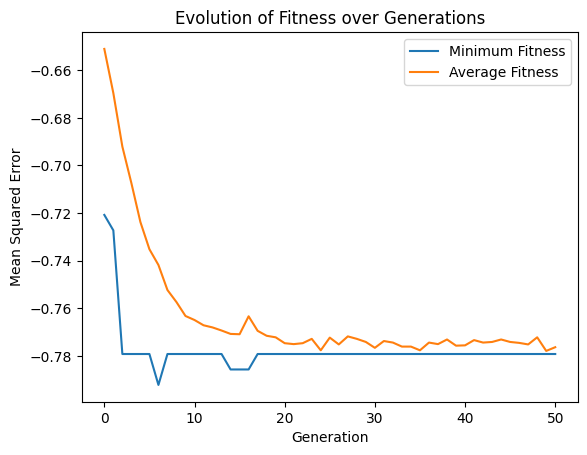

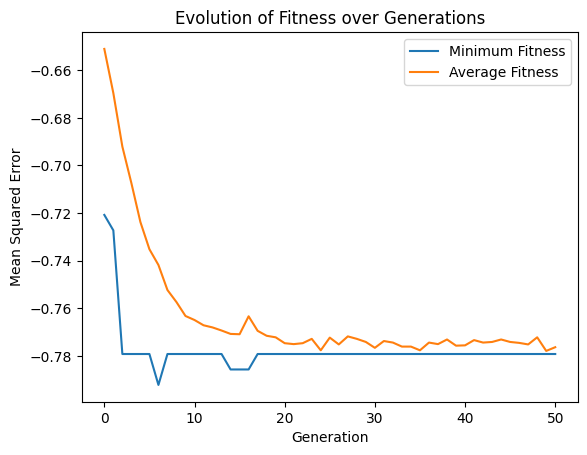

In [ ]:
# Plot the statistics
import matplotlib.pyplot as plt
gen = logbook.select("gen")
min_fit = logbook.select("min")
avg_fit = logbook.select("avg")
plt.plot(gen, min_fit, label="Minimum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations")
plt.legend()
plt.show()

In [ ]:
final_model = XGBClassifier(objective='binary:logistic',
                                 eval_metric='logloss',
                                 use_label_encoder=False,
                                 random_state=42,
                                 n_jobs=-1,
                                **optimal_hyperparameters)
final_model.fit(X_train, y_train)
print("\nFinal model trained with optimal hyperparameters.")


Final model trained with optimal hyperparameters.

Final model trained with optimal hyperparameters.


In [ ]:


from sklearn.metrics import precision_score, recall_score

y_pred = final_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"accuracy score: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")


accuracy score: 0.860655737704918
Precision: 0.8652482269503546
Recall: 0.7922077922077922
accuracy score: 0.860655737704918
Precision: 0.8652482269503546
Recall: 0.7922077922077922


#Decision Tree

In [ ]:
import random
import warnings
import numpy as np
from deap import base, creator, tools, algorithms
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Suppress warnings for cleaner output during optimization
warnings.filterwarnings('ignore')

# --- Configuration ---
# Define the bounds and types for each hyperparameter for Decision Tree
# Order: max_depth, min_samples_split, min_samples_leaf, criterion, splitter, max_features
HP_BOUNDS_LOW = [3, 2, 1, 0, 0, 0.1]
HP_BOUNDS_HIGH = [30, 20, 10, 1, 1, 1.0]
# 0: continuous, 1: discrete (integer)
# For criterion (gini/entropy) and splitter (best/random), we use integers and map them to strings.
HP_TYPES = [1, 1, 1, 1, 1, 0]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters
POPULATION_SIZE = 50
NUM_GENERATIONS = 50
CXPB = 0.7 # Crossover probability
MUTPB = 0.3 # Mutation probability

# --- DEAP Setup ---
# Define the fitness function (minimize -recall, effectively maximizing recall)
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)
toolbox = base.Toolbox()

def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    if HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function ---
def evalDT(individual, X_train, y_train, X_val, y_val):
    """
    Evaluates the fitness of an individual (set of hyperparameters)
    by training a Decision Tree Classifier and calculating the Recall Score
    on the validation set.
    """
    # Decode the hyperparameters from the individual
    # Map integer values for categorical hyperparameters
    criterion_map = {0: 'gini', 1: 'entropy'}
    splitter_map = {0: 'best', 1: 'random'}

    hyperparameters = {
        'max_depth': int(individual[0]),
        'min_samples_split': int(individual[1]),
        'min_samples_leaf': int(individual[2]),
        'criterion': criterion_map[int(individual[3])],
        'splitter': splitter_map[int(individual[4])],
        'max_features': individual[5]
    }

    # Ensure min_samples_split and min_samples_leaf are at least 1 and 2 respectively
    # based on sklearn's requirements. max_depth is handled by bounds.
    hyperparameters['min_samples_split'] = max(2, hyperparameters['min_samples_split'])
    hyperparameters['min_samples_leaf'] = max(1, hyperparameters['min_samples_leaf'])


    try:
        # Instantiate the Decision Tree Classifier model with the current hyperparameters
        model = DecisionTreeClassifier(random_state=42, **hyperparameters)

        model.fit(X_train, y_train)

        predictions = model.predict(X_val)

        # Calculate recall score, which we aim to maximize
        recall = recall_score(y_val, predictions)

        # DEAP minimizes by default, so return negative recall to maximize it
        return (-recall,)

    except Exception as e:
        # Handle potential errors during training (e.g., invalid hyperparameters)
        print(f"Error during Decision Tree training with hyperparameters {hyperparameters}: {e}")
        return (float('inf'),) # Assign infinity as fitness to penalize invalid configurations

# Register the evaluation function with the toolbox (will set data later)
toolbox.register("evaluate", evalDT, X_train=None, y_train=None, X_val=None, y_val=None)

# --- Genetic Operators ---
toolbox.register("mate", tools.cxTwoPoint)

def mutate_hyperparameters(individual, mu, sigma, indpb):
    """Mutate an individual's hyperparameters while respecting bounds and types."""
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb: # Mutate this hyperparameter with probability indpb
            if hp_type == 0: # Continuous hyperparameter
                individual[i] += random.gauss(mu, sigma[i])
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            else: # Discrete (integer) hyperparameter
                # For discrete parameters, re-select a random integer within its bounds
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [r * 0.1 if r > 0 else 0.01 for r in hp_ranges] # Handle zero range for fixed values
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.1)

toolbox.register("select", tools.selTournament, tournsize=3)

# --- Main Evolutionary Loop ---
if __name__ == '__main__':

    # Update the evaluation function with the actual training and validation data
    toolbox.unregister("evaluate")
    toolbox.register("evaluate", evalDT, X_train=X_train, y_train=y_train, X_val=X_test, y_val=y_test)

    # Create the initial population
    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    # Evaluate the fitness of the initial population
    print("Evaluating initial population...")
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB,
                                              ngen=NUM_GENERATIONS, stats=stats,
                                              halloffame=hof, verbose=True)

    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        optimal_recall = -best_individual.fitness.values[0] # Convert back to positive recall

        # Decode the best hyperparameters for Decision Tree
        criterion_map = {0: 'gini', 1: 'entropy'}
        splitter_map = {0: 'best', 1: 'random'}

        optimal_hyperparameters = {
            'max_depth': int(best_individual[0]),
            'min_samples_split': int(best_individual[1]),
            'min_samples_leaf': int(best_individual[2]),
            'criterion': criterion_map[int(best_individual[3])],
            'splitter': splitter_map[int(best_individual[4])],
            'max_features': best_individual[5]
        }

        print(f"Optimization finished. Best Recall: {optimal_recall:.4f}")
        print("Optimal Hyperparameters found:")
        for hp, value in optimal_hyperparameters.items():
            print(f"  {hp}: {value}")
    else:
        print("Optimization did not find a valid individual in the Hall of Fame.")

Creating initial population of size 50...
Evaluating initial population...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg      	std      	min      	max      
0  	0     	-0.658182	0.0832766	-0.792208	-0.305195
1  	38    	-0.705714	0.0439921	-0.792208	-0.623377
2  	35    	-0.714805	0.063142 	-0.792208	-0.480519
3  	38    	-0.747013	0.0524965	-0.831169	-0.597403
4  	38    	-0.766753	0.036798 	-0.792208	-0.642857
5  	36    	-0.781299	0.0245534	-0.792208	-0.688312
6  	39    	-0.765974	0.0399223	-0.792208	-0.675325
7  	39    	-0.764416	0.0376856	-0.792208	-0.688312
8  	41    	-0.767403	0.03998  	-0.805195	-0.662338
9  	43    	-0.772208	0.0351332	-0.805195	-0.675325
10 	43    	-0.787532	0.0230145	-0.805195	-0.694805
11 	37    	-0.791688	0.0272678	-0.811688	-0.668831
12 	43    	-0.80013 	0.0158681	-0.811688	-0.727273
13 	41    	-0.797273	0.0241324	-0.811688	-0.681818
14 	46    	-0.795325	0.0329635	-0.811688	-0.649351
15 	37    	-0.801429	0.023631 	-0.811688	-0.655844
1

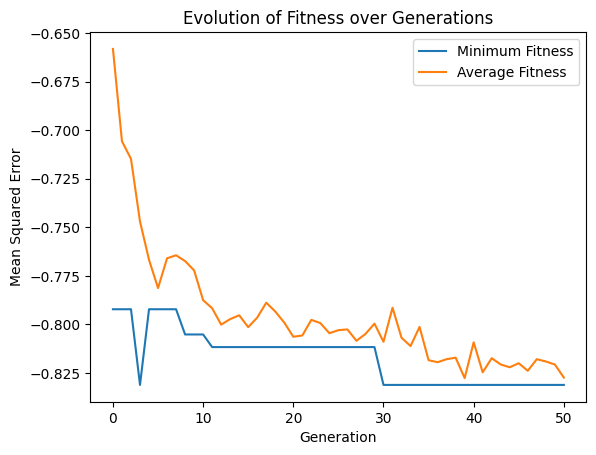

In [ ]:
import matplotlib.pyplot as plt
gen = logbook.select("gen")
min_fit = logbook.select("min")
avg_fit = logbook.select("avg")
plt.plot(gen, min_fit, label="Minimum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations")
plt.legend()
plt.show()

In [ ]:
final_model_dtc = DecisionTreeClassifier(random_state=42, **optimal_hyperparameters)
final_model_dtc.fit(X_train, y_train)
print("\nFinal model trained with optimal hyperparameters.")


Final model trained with optimal hyperparameters.


In [ ]:
from sklearn.metrics import precision_score, recall_score

y_pred = final_model_dtc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"accuracy score: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

accuracy score: 0.8333333333333334
Precision: 0.7852760736196319
Recall: 0.8311688311688312



#Random Forest

In [ ]:
import random
import warnings
import numpy as np
from deap import base, creator, tools, algorithms
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Suppress warnings for cleaner output during optimization
warnings.filterwarnings('ignore')

# --- Configuration ---
# Define the bounds and types for each hyperparameter for Random Forest
# Order: n_estimators, max_depth, min_samples_split, min_samples_leaf, criterion, max_features
HP_BOUNDS_LOW = [50, 3, 2, 1, 0, 0.1] # criterion: 0 for 'gini'
HP_BOUNDS_HIGH = [500, 30, 20, 10, 1, 1.0] # criterion: 1 for 'entropy'
# 0: continuous, 1: discrete (integer)
HP_TYPES = [1, 1, 1, 1, 1, 0]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters
POPULATION_SIZE = 50
NUM_GENERATIONS = 50
CXPB = 0.7 # Crossover probability
MUTPB = 0.3 # Mutation probability

# --- DEAP Setup ---
# Define the fitness function (minimize -recall, effectively maximizing recall)
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)
toolbox = base.Toolbox()

def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    if HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function ---
def evalRF(individual, X_train, y_train, X_val, y_val):
    """
    Evaluates the fitness of an individual (set of hyperparameters)
    by training a Random Forest Classifier and calculating the Recall Score
    on the validation set.
    """
    # Decode the hyperparameters from the individual
    # Map integer values for categorical hyperparameters
    criterion_map = {0: 'gini', 1: 'entropy'}

    hyperparameters = {
        'n_estimators': int(individual[0]),
        'max_depth': int(individual[1]),
        'min_samples_split': int(individual[2]),
        'min_samples_leaf': int(individual[3]),
        'criterion': criterion_map[int(individual[4])],
        'max_features': individual[5]
    }

    # Ensure min_samples_split and min_samples_leaf are at least 1 and 2 respectively
    hyperparameters['min_samples_split'] = max(2, hyperparameters['min_samples_split'])
    hyperparameters['min_samples_leaf'] = max(1, hyperparameters['min_samples_leaf'])
    # Ensure n_estimators is at least 1
    hyperparameters['n_estimators'] = max(1, hyperparameters['n_estimators'])
    # Ensure max_features is within (0, 1] if a float
    hyperparameters['max_features'] = max(0.001, min(1.0, hyperparameters['max_features'])) # Avoid 0 max_features

    try:
        # Instantiate the Random Forest Classifier model with the current hyperparameters
        model = RandomForestClassifier(random_state=42, n_jobs=-1, **hyperparameters) # n_jobs=-1 for parallel processing

        model.fit(X_train, y_train)

        predictions = model.predict(X_val)

        # Calculate recall score, which we aim to maximize
        recall = recall_score(y_val, predictions)

        # DEAP minimizes by default, so return negative recall to maximize it
        return (-recall,)

    except Exception as e:
        # Handle potential errors during training (e.g., invalid hyperparameters)
        print(f"Error during Random Forest training with hyperparameters {hyperparameters}: {e}")
        return (float('inf'),) # Assign infinity as fitness to penalize invalid configurations

# Register the evaluation function with the toolbox (will set data later)
toolbox.register("evaluate", evalRF, X_train=None, y_train=None, X_val=None, y_val=None)

# --- Genetic Operators ---
toolbox.register("mate", tools.cxTwoPoint)

def mutate_hyperparameters(individual, mu, sigma, indpb):
    """Mutate an individual's hyperparameters while respecting bounds and types."""
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb: # Mutate this hyperparameter with probability indpb
            if hp_type == 0: # Continuous hyperparameter
                individual[i] += random.gauss(mu, sigma[i])
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            else: # Discrete (integer) hyperparameter
                # For discrete parameters, re-select a random integer within its bounds
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
# Avoid division by zero if a range is 0 (i.e., fixed value)
mutation_sigma = [r * 0.1 if r > 0 else 0.01 for r in hp_ranges]
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.1)

toolbox.register("select", tools.selTournament, tournsize=3)

# --- Main Evolutionary Loop ---
if __name__ == '__main__':


    # Update the evaluation function with the actual training and validation data
    toolbox.unregister("evaluate")
    toolbox.register("evaluate", evalRF, X_train=X_train, y_train=y_train, X_val=X_test, y_val=y_test)

    # Create the initial population
    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    # Evaluate the fitness of the initial population
    print("Evaluating initial population...")
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB,
                                              ngen=NUM_GENERATIONS, stats=stats,
                                              halloffame=hof, verbose=True)

    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        optimal_recall = -best_individual.fitness.values[0] # Convert back to positive recall

        # Decode the best hyperparameters for Random Forest
        criterion_map = {0: 'gini', 1: 'entropy'}

        optimal_hyperparameters = {
            'n_estimators': int(best_individual[0]),
            'max_depth': int(best_individual[1]),
            'min_samples_split': int(best_individual[2]),
            'min_samples_leaf': int(best_individual[3]),
            'criterion': criterion_map[int(best_individual[4])],
            'max_features': best_individual[5]
        }

        print(f"Optimization finished. Best Recall: {optimal_recall:.4f}")
        print("Optimal Hyperparameters found:")
        for hp, value in optimal_hyperparameters.items():
            print(f"  {hp}: {value}")
    else:
        print("Optimization did not find a valid individual in the Hall of Fame.")

Creating initial population of size 50...
Evaluating initial population...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg      	std      	min      	max      
0  	0     	-0.718182	0.0328805	-0.785714	-0.623377
1  	39    	-0.735844	0.0199273	-0.785714	-0.694805
2  	36    	-0.749091	0.0171192	-0.785714	-0.694805
3  	41    	-0.765455	0.0151809	-0.785714	-0.733766
4  	41    	-0.772468	0.0143423	-0.785714	-0.714286
5  	40    	-0.777792	0.011042 	-0.785714	-0.74026 
6  	42    	-0.78026 	0.0129454	-0.785714	-0.727273
7  	40    	-0.783117	0.00899767	-0.785714	-0.74026 
8  	41    	-0.780519	0.0125242 	-0.785714	-0.74026 
9  	41    	-0.782468	0.0113404 	-0.785714	-0.733766
10 	44    	-0.783896	0.00735115	-0.785714	-0.74026 
11 	39    	-0.782727	0.010647  	-0.785714	-0.733766
12 	39    	-0.783506	0.00847745	-0.785714	-0.74026 
13 	40    	-0.782078	0.0144127 	-0.785714	-0.707792
14 	40    	-0.78039 	0.0219895 	-0.785714	-0.642857
15 	38    	-0.781558	0.013973  	-0.785714	-0

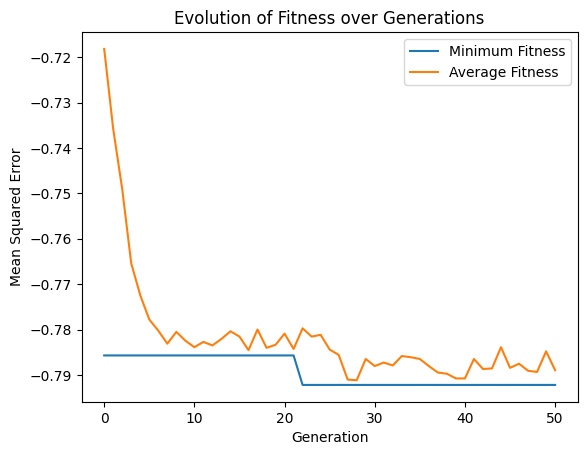

In [ ]:
import matplotlib.pyplot as plt
gen = logbook.select("gen")
min_fit = logbook.select("min")
avg_fit = logbook.select("avg")
plt.plot(gen, min_fit, label="Minimum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations")
plt.legend()
plt.show()

In [ ]:
final_model_frc = RandomForestClassifier(random_state=42, n_jobs=-1, **optimal_hyperparameters)
final_model_frc.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=24,
                       max_features=0.6551905869268003, min_samples_split=10,
                       n_estimators=160, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import precision_score, recall_score

y_pred = final_model_frc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"accuracy score: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

accuracy score: 0.8469945355191257
Precision: 0.8356164383561644
Recall: 0.7922077922077922


In [ ]:
# saving model

import joblib
filename = '/content/drive/MyDrive/colab-model/Random_forest_stability0.025_perovskites.joblib'
joblib.dump(final_model_frc, filename)

print(f"Model saved successfully to {filename}")

Model saved successfully to /content/drive/MyDrive/colab-model/Random_forest_stability0.025_perovskites.joblib


In [ ]:
import joblib
filename = '/content/drive/MyDrive/colab-model/Decision_tree_stability0.025_perovskites.joblib'
joblib.dump(final_model_frc, filename)

print(f"Model saved successfully to {filename}")

Model saved successfully to /content/drive/MyDrive/colab-model/Decision_tree_stability0.025_perovskites.joblib


In [ ]:
import joblib
filename = '/content/drive/MyDrive/colab-model/XGB25-06-25_stability0.025_perovskites.joblib'
joblib.dump(final_model, filename)

print(f"Model saved successfully to {filename}")

Model saved successfully to /content/drive/MyDrive/colab-model/XGB25-06-25_stability0.025_perovskites.joblib
